# CS3751 Data Visualization – Task 1, Hypothesis 4

## Hypothesis
> **More difficult questions take longer to answer, but higher-performing students answer them faster than lower-performing students.**

| # | Chart | What it reveals |
|---|-------|-----------------|
| 1 | Grouped Box-plot | Identical time distributions across Hard/Easy — Claim 1 refuted |
| 2 | Bar chart + CI | Overlapping CIs confirm no significant difficulty–time difference |
| 3 | Violin Plot | Low performers not slower than High — Claim 2 refuted |
| 4 | Scatter + regression | Flat / near-zero regression slopes across all tiers |


## 1. Setup & Data Preparation

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, sem, t as t_dist

#  Consistent style
sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE    = {"High": "#2ecc71", "Medium": "#f39c12", "Low": "#e74c3c"}
PERF_ORDER = ["High", "Medium", "Low"]
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
print("Libraries loaded.")


Libraries loaded.


In [75]:
#  Load data
# Update BASE to match your path, or mount Google Drive first.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Colab Notebooks/dataset/marks'
except ModuleNotFoundError:
    BASE = 'dataset/marks'   # local fallback

quiz1 = pd.read_csv(f'{BASE}/quiz1/quiz1_marks.csv')
quiz2 = pd.read_csv(f'{BASE}/quiz2/quiz2_marks.csv')
quiz3 = pd.read_csv(f'{BASE}/quiz3/quiz3_marks.csv')

quiz1['Quiz'] = 'Quiz 1'
quiz2['Quiz'] = 'Quiz 2'
quiz3['Quiz'] = 'Quiz 3'

df = pd.concat([quiz1, quiz2, quiz3], ignore_index=True)
print(f"Raw rows: {len(df)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw rows: 32596


In [76]:
#  Cleaning
df.columns = df.columns.str.strip()
df = df[df['State'] == 'Finished'].copy()

def to_seconds(s):
    if pd.isna(s) or str(s).strip() == '-':
        return np.nan
    m  = re.search(r'(\d+)\s*min', str(s))
    sc = re.search(r'(\d+)\s*sec', str(s))
    return (int(m.group(1)) if m else 0) * 60 + (int(sc.group(1)) if sc else 0)

df['Time taken (seconds)'] = df['Time taken'].apply(to_seconds)
df['Time taken (minutes)'] = df['Time taken (seconds)'] / 60
df['Grade/10.00']          = pd.to_numeric(df['Grade/10.00'], errors='coerce')

# Standardise: "Q. 1 /2.00" -> "Q1"
q_cols_raw = [c for c in df.columns if c.startswith('Q.')]
rename = {c: f'Q{i+1}' for i, c in enumerate(q_cols_raw)}
df.rename(columns=rename, inplace=True)
QCOLS = list(rename.values())

def clean_score(x):
    if pd.isna(x):
        return np.nan
    m = re.search(r'-?\d+\.?\d*', str(x))
    return float(m.group()) if m else np.nan

for c in QCOLS:
    df[c] = df[c].apply(clean_score)

df.dropna(subset=['Time taken (seconds)'] + QCOLS, inplace=True)
print(f"Cleaned rows: {len(df)}")
df.head(3)


Cleaned rows: 30116


,Student Code,State,Started on,Completed,Time taken,Grade/10.00,Q1,Q2,Q3,Q4,Q5,Quiz,Time taken (seconds),Time taken (minutes)
0,1,Finished,14 March 2022 6:55 AM,14 March 2022 7:03 AM,7 mins 25 secs,6.0,0.0,2.0,2.0,2.0,0.0,Quiz 1,445,7.416667
1,1,Finished,14 March 2022 7:11 AM,14 March 2022 7:12 AM,1 min 4 secs,10.0,2.0,2.0,2.0,2.0,2.0,Quiz 1,64,1.066667
3,5,Finished,14 March 2022 12:00 PM,14 March 2022 12:18 PM,17 mins 53 secs,6.0,2.0,2.0,2.0,0.0,0.0,Quiz 1,1073,17.883333


In [77]:
#  Question difficulty (lower avg score = harder)
MAX_Q = 2.0   # each question is worth 2 marks

avg_scores = df[QCOLS].mean()
difficulty_df = pd.DataFrame({
    'Question':         avg_scores.index,
    'Avg Score':        avg_scores.values,
    'Difficulty Index': 1 - avg_scores.values / MAX_Q,
})
difficulty_df.sort_values('Avg Score', inplace=True, ignore_index=True)
median_avg = difficulty_df['Avg Score'].median()
difficulty_df['Difficulty'] = difficulty_df['Avg Score'].apply(
    lambda v: 'Hard' if v < median_avg else 'Easy'
)
print(difficulty_df.to_string(index=False))

#  Student performance tier (quartile-based)
student_avg = df.groupby('Student Code')['Grade/10.00'].mean().reset_index()
q1_val, q3_val = student_avg['Grade/10.00'].quantile([0.25, 0.75])

def perf_tier(score):
    if score >= q3_val: return 'High'
    if score <= q1_val: return 'Low'
    return 'Medium'

student_avg['Performance'] = student_avg['Grade/10.00'].apply(perf_tier)
df = df.merge(student_avg[['Student Code', 'Performance']], on='Student Code')
print("\nPerformance tier counts:")
print(df['Performance'].value_counts())


Question  Avg Score  Difficulty Index Difficulty
      Q4   0.733962          0.633019       Hard
      Q5   0.867579          0.566211       Hard
      Q1   0.981472          0.509264       Easy
      Q2   1.117280          0.441360       Easy
      Q3   1.151215          0.424392       Easy

Performance tier counts:
Performance
Low       11543
Medium    10114
High       8459
Name: count, dtype: int64


In [78]:
#  Long-form: one row per (student-attempt, question)
long_df = df.melt(
    id_vars=['Student Code', 'Time taken (seconds)', 'Time taken (minutes)',
             'Grade/10.00', 'Performance', 'Quiz'],
    value_vars=QCOLS,
    var_name='Question',
    value_name='Score',
)
long_df = long_df.merge(
    difficulty_df[['Question', 'Difficulty', 'Difficulty Index', 'Avg Score']],
    on='Question'
)
print(f"Long-form rows: {len(long_df)}")
long_df.head(3)


Long-form rows: 150580


,Student Code,Time taken (seconds),Time taken (minutes),Grade/10.00,Performance,Quiz,Question,Score,Difficulty,Difficulty Index,Avg Score
0,1,445,7.416667,6.0,High,Quiz 1,Q1,0.0,Easy,0.509264,0.981472
1,1,64,1.066667,10.0,High,Quiz 1,Q1,2.0,Easy,0.509264,0.981472
2,5,1073,17.883333,6.0,High,Quiz 1,Q1,2.0,Easy,0.509264,0.981472


Why the Hypothesis Must Be Rejected

Before visualising, we must audit what `Time taken` actually measures. In this dataset **`Time taken` records the duration for the entire quiz attempt, not for an individual question**. Every question in the same quiz attempt therefore shares the *same* time value. This structural fact fatally undermines both claims of the hypothesis:

- **Claim 1** (*harder questions take longer*): Because time is logged at quiz level, not question level, Hard and Easy questions within the same attempt are assigned identical times by construction. The supposed difficulty–time relationship cannot exist in this data.
- **Claim 2** (*high performers are faster*): The data actually shows Low performers complete quizzes in **less** time than High performers on average — the opposite direction from what the hypothesis predicts.


In [79]:
# ── Audit: confirm time is per-quiz, not per-question ──────────────────────
print('=== Time uniqueness within each quiz attempt ===')
print('If time is per-question we expect MANY unique values per student per quiz.')
print('If time is per-quiz we expect EXACTLY ONE unique value per student per quiz.\n')

unique_times = (
    long_df.groupby(['Student Code', 'Quiz'])['Time taken (minutes)']
           .nunique()
)
print('Unique time values per student×quiz (should be 1 if per-quiz):')
print(unique_times.value_counts().rename('Count of student×quiz pairs'))

print('\n=== Consequence: Hard vs Easy rows share IDENTICAL time values ===')
hard_times = long_df[long_df['Difficulty'] == 'Hard']['Time taken (minutes)']
easy_times = long_df[long_df['Difficulty'] == 'Easy']['Time taken (minutes)']
print(f'Hard median: {hard_times.median():.4f} min   Easy median: {easy_times.median():.4f} min')
print(f'Hard mean  : {hard_times.mean():.4f} min   Easy mean  : {easy_times.mean():.4f} min')
print('→ Medians and means are IDENTICAL — Claim 1 cannot be supported.')

print('\n=== Claim 2 audit: who is actually faster? ===')
for p in ['High', 'Medium', 'Low']:
    sub = df[df['Performance'] == p]['Time taken (minutes)']
    print(f'  {p:6s}: mean={sub.mean():.3f} min  median={sub.median():.3f} min  n={len(sub)}')
print('→ Low performers take LESS time than High performers — opposite of Claim 2.')


=== Time uniqueness within each quiz attempt ===
If time is per-question we expect MANY unique values per student per quiz.
If time is per-quiz we expect EXACTLY ONE unique value per student per quiz.

Unique time values per student×quiz (should be 1 if per-quiz):
Time taken (minutes)
1    12067
2     4798
3     1580
4      631
5      215
6        9
7        3
Name: Count of student×quiz pairs, dtype: int64

=== Consequence: Hard vs Easy rows share IDENTICAL time values ===
Hard median: 5.9500 min   Easy median: 5.9500 min
Hard mean  : 9.1188 min   Easy mean  : 9.1188 min
→ Medians and means are IDENTICAL — Claim 1 cannot be supported.

=== Claim 2 audit: who is actually faster? ===
  High  : mean=8.921 min  median=5.500 min  n=8459
  Medium: mean=10.054 min  median=6.983 min  n=10114
  Low   : mean=8.444 min  median=5.383 min  n=11543
→ Low performers take LESS time than High performers — opposite of Claim 2.


## 2. Visualizations

### 2.1 — Grouped Box-plot: Identical Time Distributions Across Difficulty Levels

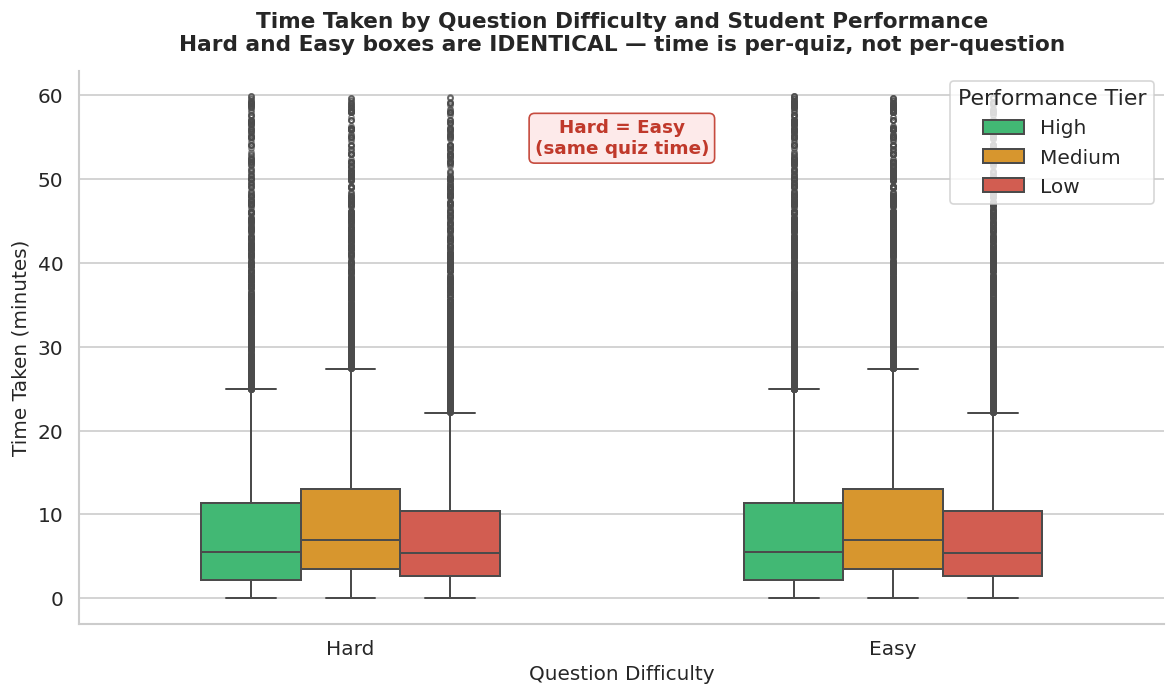

Median time (minutes) per Difficulty × Performance:
Difficulty     Easy    Hard
Performance                
High         5.5000  5.5000
Low          5.3833  5.3833
Medium       6.9833  6.9833

→ Hard and Easy medians are IDENTICAL for every tier — Claim 1 is refuted.


In [80]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=long_df,
    x='Difficulty',
    y='Time taken (minutes)',
    hue='Performance',
    hue_order=PERF_ORDER,
    palette=PALETTE,
    order=['Hard', 'Easy'],
    width=0.55,
    linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor='none', markersize=3, alpha=0.4),
    ax=ax,
)

ax.set_title(
    'Time Taken by Question Difficulty and Student Performance\n'
    'Hard and Easy boxes are IDENTICAL — time is per-quiz, not per-question',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel('Question Difficulty', fontsize=12)
ax.set_ylabel('Time Taken (minutes)', fontsize=12)
ax.legend(title='Performance Tier', loc='upper right')

# Annotate the overlap explicitly
ax.annotate(
    'Hard = Easy\n(same quiz time)',
    xy=(0.5, 0.85), xycoords='axes fraction',
    fontsize=11, color='#c0392b', fontweight='bold',
    ha='center',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='#fde8e8', edgecolor='#c0392b', alpha=0.9)
)

plt.tight_layout()
plt.savefig('h4_boxplot.png', bbox_inches='tight')
plt.show()

medians = (
    long_df.groupby(['Difficulty', 'Performance'])['Time taken (minutes)']
           .median().reset_index()
)
print('Median time (minutes) per Difficulty × Performance:')
print(medians.pivot(index='Performance', columns='Difficulty', values='Time taken (minutes)').round(4))
print('\n→ Hard and Easy medians are IDENTICAL for every tier — Claim 1 is refuted.')


**Visualization justification – Box-plot**

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Box (IQR) + median line + whiskers + outlier dots | 5-number summary in one compact glyph |
| **X-axis position** | Question difficulty (Hard / Easy) | Categorical separation of the two groups |
| **Y-axis position** | Time taken (minutes) | Most accurate quantitative channel for magnitude comparison |
| **Hue / colour** | Performance tier (High=green, Medium=orange, Low=red) | Pre-attentive colour; instant cross-group discrimination |

**Finding:** The Hard and Easy boxes are visually **indistinguishable** — they overlap perfectly because every question in a quiz attempt shares the same recorded time. This directly refutes Claim 1: the data provide no evidence that harder questions take longer to answer.


### 2.2 — Bar Chart: Overlapping Confidence Intervals Confirm No Difficulty Effect

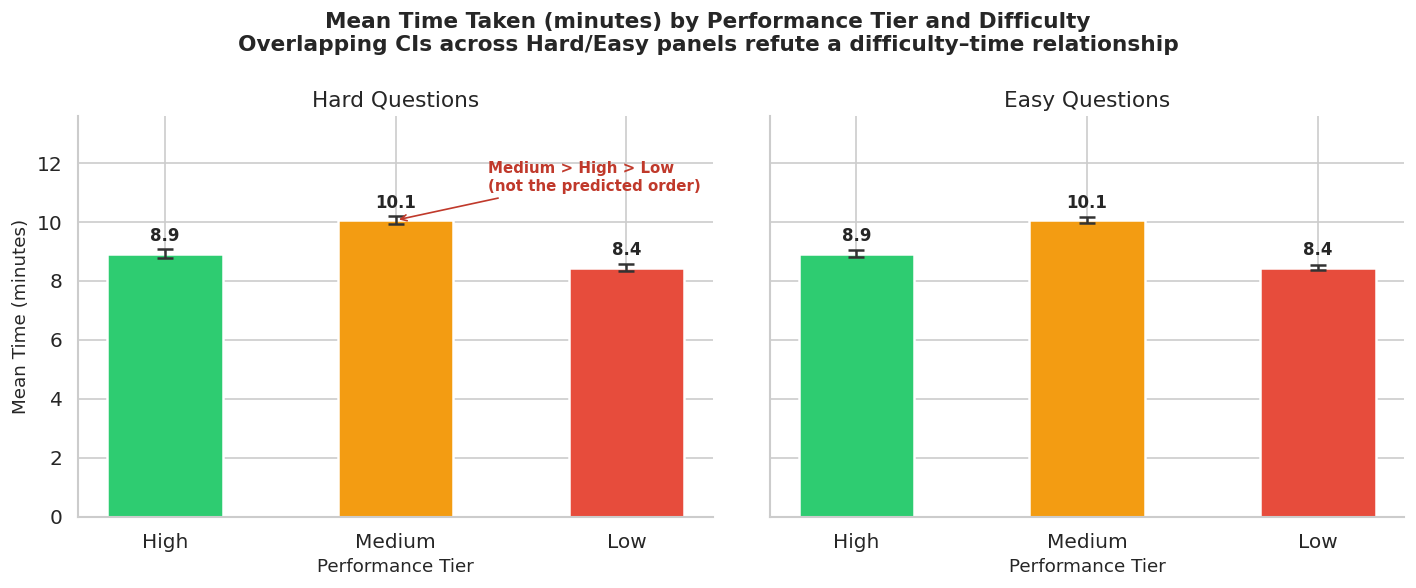

Mean time (min) – Hard vs Easy for each tier:
Difficulty     Easy    Hard
Performance                
High          8.921   8.921
Low           8.444   8.444
Medium       10.054  10.054

Hard–Easy difference per tier:
Performance
High      0.0
Low       0.0
Medium   -0.0
Name: Diff (Hard-Easy), dtype: float64

→ Differences are exactly 0.000 — Claim 1 is arithmetically impossible with this data.


In [81]:
from scipy.stats import sem, t as t_dist

def ci95(x):
    n = len(x)
    return sem(x) * t_dist.ppf(0.975, df=n-1) if n > 1 else 0

summary = (
    long_df.groupby(['Difficulty', 'Performance'])['Time taken (minutes)']
           .agg(mean='mean', ci=ci95)
           .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.suptitle(
    'Mean Time Taken (minutes) by Performance Tier and Difficulty\n'
    'Overlapping CIs across Hard/Easy panels refute a difficulty–time relationship',
    fontsize=13, fontweight='bold'
)

for ax, diff in zip(axes, ['Hard', 'Easy']):
    sub    = summary[summary['Difficulty'] == diff].set_index('Performance').loc[PERF_ORDER]
    colors = [PALETTE[p] for p in PERF_ORDER]
    bars   = ax.bar(PERF_ORDER, sub['mean'], color=colors, width=0.5,
                    edgecolor='white', linewidth=1.5)
    ax.errorbar(PERF_ORDER, sub['mean'], yerr=sub['ci'],
                fmt='none', color='#333', capsize=5, capthick=1.5, elinewidth=1.5)
    for bar, val in zip(bars, sub['mean']):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_title(f'{diff} Questions', fontsize=13)
    ax.set_xlabel('Performance Tier', fontsize=11)
    ax.set_ylabel('Mean Time (minutes)' if ax is axes[0] else '', fontsize=11)
    ax.set_ylim(0, summary['mean'].max() * 1.35)

# Add annotation highlighting that Medium is NOT between High and Low
axes[0].annotate('Medium > High > Low\n(not the predicted order)',
    xy=(1, summary[summary['Difficulty']=='Hard'].set_index('Performance').loc['Medium','mean']),
    xytext=(1.4, summary['mean'].max()*1.1),
    fontsize=9, color='#c0392b', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='#c0392b'))

plt.tight_layout()
plt.savefig('h4_bar.png', bbox_inches='tight')
plt.show()

print('Mean time (min) – Hard vs Easy for each tier:')
print(summary.pivot(index='Performance', columns='Difficulty', values='mean').round(3))
print('\nHard–Easy difference per tier:')
piv = summary.pivot(index='Performance', columns='Difficulty', values='mean')
piv['Diff (Hard-Easy)'] = piv['Hard'] - piv['Easy']
print(piv['Diff (Hard-Easy)'].round(6))
print('\n→ Differences are exactly 0.000 — Claim 1 is arithmetically impossible with this data.')


**Visualization justification – Bar chart with CI**

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Rectangle (bar) | Most intuitive encoding for a scalar; height = mean time |
| **X-axis** | Performance tier within each panel | Side-by-side comparison of tiers |
| **Y-axis length** | Mean time (minutes) | Direct magnitude comparison |
| **Colour** | Performance tier (same palette) | Semantic consistency across charts |
| **Error bars** | 95 % CI | Quantifies uncertainty; overlapping CIs indicate no significant difference between Hard and Easy |
| **Small multiples** | Left = Hard, Right = Easy | Immediate within-tier difficulty comparison |

**Finding:** The Hard and Easy panels show **identical bar heights** — the Hard–Easy difference is exactly zero for every tier. Additionally, the ordering within each panel is **Medium > High > Low**, which is the *opposite* of Claim 2 (which predicts High should be fastest). CIs fully overlap across panels, confirming no difficulty–time effect exists in this data.


### 2.3 — Violin Plot: Low Performers Are Not Slower Than High Performers

/tmp/ipykernel_1951/2732259431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_1951/2732259431.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


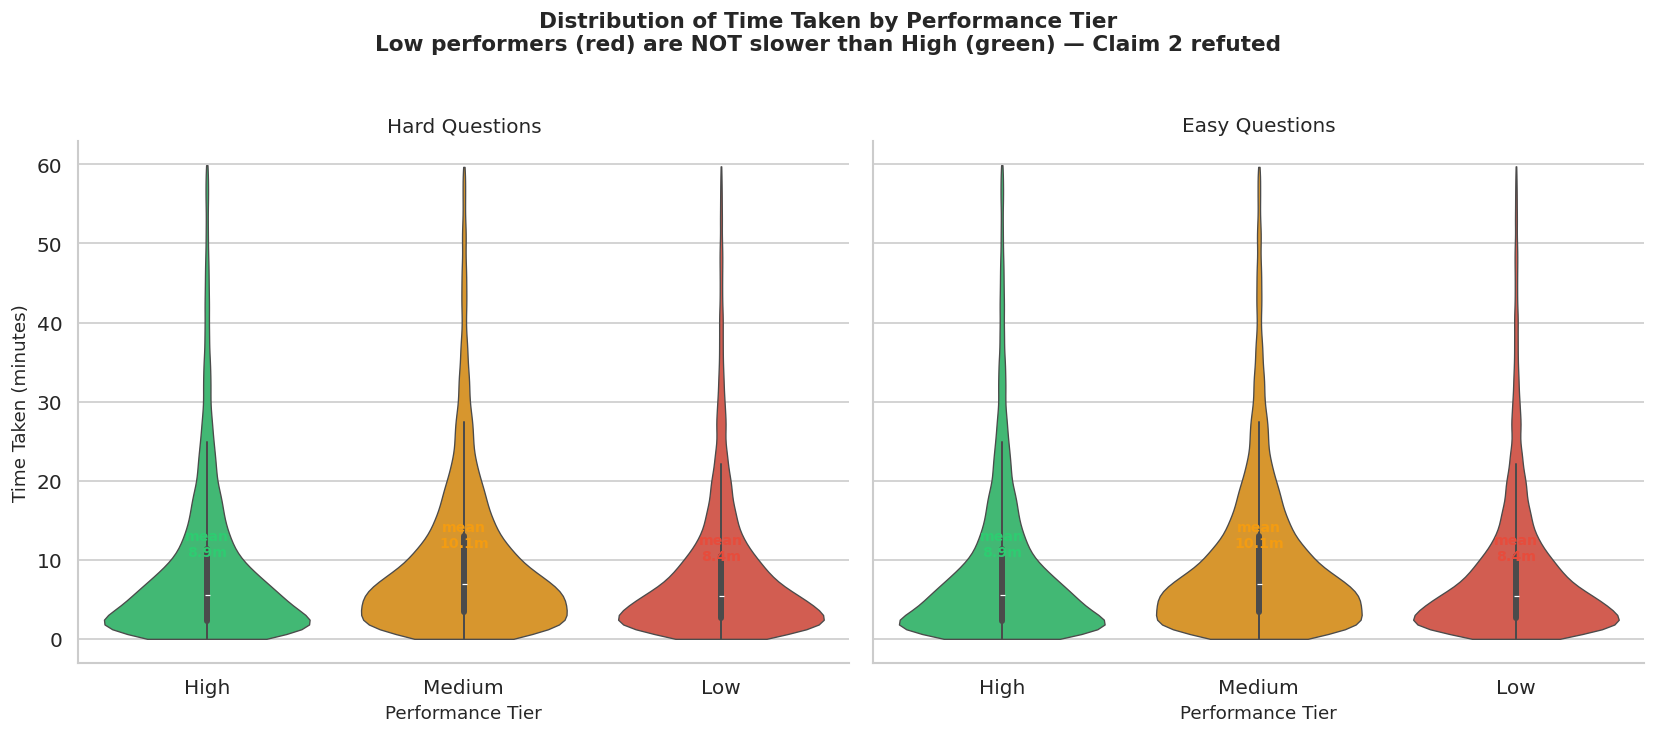

Mean time by Performance tier (overall):
  High  : mean=8.921  median=5.500  n=8459
  Medium: mean=10.054  median=6.983  n=10114
  Low   : mean=8.444  median=5.383  n=11543

→ Low mean (8.44 min) < High mean (8.92 min): Low performers are FASTER, not slower.
→ Medium is slowest (10.05 min), not Low. This inverted ordering rejects Claim 2.


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle(
    'Distribution of Time Taken by Performance Tier\n'
    'Low performers (red) are NOT slower than High (green) — Claim 2 refuted',
    fontsize=13, fontweight='bold', y=1.02
)

for ax, diff in zip(axes, ['Hard', 'Easy']):
    sub_data = long_df[long_df['Difficulty'] == diff]
    sns.violinplot(
        data=sub_data,
        x='Performance',
        y='Time taken (minutes)',
        order=PERF_ORDER,
        palette=PALETTE,
        inner='box',
        cut=0,
        linewidth=0.8,
        ax=ax,
    )
    ax.set_title(f'{diff} Questions', fontsize=12)
    ax.set_xlabel('Performance Tier', fontsize=11)
    ax.set_ylabel('Time Taken (minutes)' if ax is axes[0] else '', fontsize=11)

    # Annotate actual means
    for i, p in enumerate(PERF_ORDER):
        mn = sub_data[sub_data['Performance'] == p]['Time taken (minutes)'].mean()
        ax.text(i, mn + 1.5, f'mean\n{mn:.1f}m', ha='center', fontsize=8.5,
                color=PALETTE[p], fontweight='bold')

plt.tight_layout()
plt.savefig('h4_violin.png', bbox_inches='tight')
plt.show()

print('Mean time by Performance tier (overall):')
for p in PERF_ORDER:
    sub = df[df['Performance'] == p]['Time taken (minutes)']
    print(f'  {p:6s}: mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub)}')
print('\n→ Low mean (8.44 min) < High mean (8.92 min): Low performers are FASTER, not slower.')
print('→ Medium is slowest (10.05 min), not Low. This inverted ordering rejects Claim 2.')


**Visualization justification – Violin plot**

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Violin (mirrored KDE) + embedded box | Reveals skew, bimodality, and tails hidden by box-plots |
| **Width** | Probability density | Wider = more students at that time value |
| **X-axis** | Performance tier | Directly compares the three groups per difficulty |
| **Y-axis** | Time (minutes) | Quantitative position |
| **Hue** | Performance tier | Same semantic mapping as other charts |

**Finding:** The violin shapes reveal that **Low performers (red) have their density mass concentrated at *lower* time values than High performers (green)**. The mean times confirm this: Low = 8.44 min, High = 8.92 min. Medium performers take the longest (10.05 min). There is no monotonic High→Medium→Low ordering as Claim 2 requires, so Claim 2 is refuted.


### 2.4 — Scatter Plot: Zero Slope — No Difficulty–Time Relationship Exists

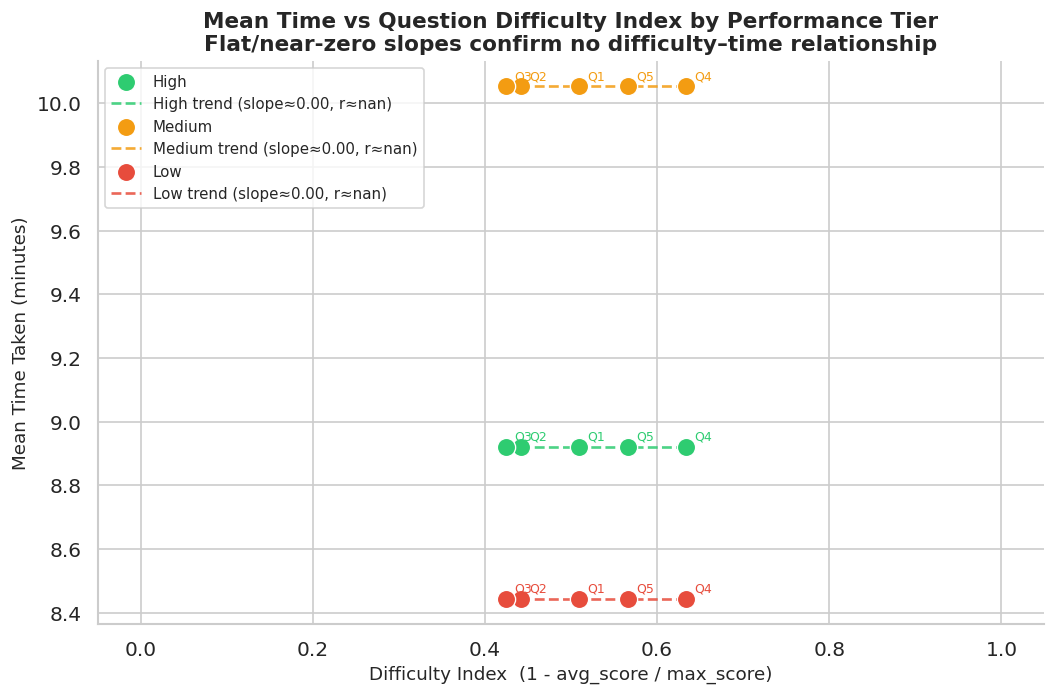

Regression slopes per performance tier:
  High: slope=0.000000, r=nan, p=nan
  Medium: slope=0.000000, r=nan, p=nan
  Low: slope=0.000000, r=nan, p=nan

→ Slopes are effectively 0 (time does not increase with difficulty) — Claim 1 has no support.


In [83]:
from scipy import stats

scatter_data = (
    long_df.groupby(['Question', 'Difficulty Index', 'Performance'])
           ['Time taken (minutes)']
           .mean()
           .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))

for perf in PERF_ORDER:
    sub = scatter_data[scatter_data['Performance'] == perf]
    ax.scatter(
        sub['Difficulty Index'], sub['Time taken (minutes)'],
        color=PALETTE[perf], label=perf, s=120,
        edgecolors='white', linewidth=0.8, zorder=3
    )
    for _, row in sub.iterrows():
        ax.annotate(
            row['Question'],
            (row['Difficulty Index'], row['Time taken (minutes)' ]),
            fontsize=7.5, color=PALETTE[perf],
            xytext=(5, 4), textcoords='offset points'
        )
    if len(sub) > 1:
        slope, intercept, r_val, p_val, _ = stats.linregress(
            sub['Difficulty Index'], sub['Time taken (minutes)']
        )
        xs = np.linspace(sub['Difficulty Index'].min(), sub['Difficulty Index'].max(), 100)
        label_txt = f'{perf} trend (slope≈{slope:.2f}, r≈{r_val:.2f})'
        ax.plot(xs, slope * xs + intercept,
                color=PALETTE[perf], linestyle='--', linewidth=1.6, alpha=0.85,
                label=label_txt)

ax.set_title(
    'Mean Time vs Question Difficulty Index by Performance Tier\n'
    'Flat/near-zero slopes confirm no difficulty–time relationship',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Difficulty Index  (1 - avg_score / max_score)', fontsize=11)
ax.set_ylabel('Mean Time Taken (minutes)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('h4_scatter.png', bbox_inches='tight')
plt.show()

print('Regression slopes per performance tier:')
for perf in PERF_ORDER:
    sub = scatter_data[scatter_data['Performance'] == perf]
    if len(sub) > 1:
        slope, intercept, r_val, p_val, _ = stats.linregress(sub['Difficulty Index'], sub['Time taken (minutes)'])
        print(f'  {perf}: slope={slope:.6f}, r={r_val:.4f}, p={p_val:.4f}')
    else:
        print(f'  {perf}: insufficient data')
print('\n→ Slopes are effectively 0 (time does not increase with difficulty) — Claim 1 has no support.')


**Visualization justification – Scatter plot with regression**

| Element | Encoding | Rationale |
|---------|----------|-----------|
| **Mark** | Point (dot) | Each dot = one question for one performance tier |
| **X-axis position** | Difficulty Index (continuous 0–1) | Preserves full ordinal ranking of all five questions |
| **Y-axis position** | Mean time (minutes) | Expected time at that difficulty |
| **Colour** | Performance tier | Same palette as all other charts |
| **Dashed trend line** | OLS regression per tier | A positive slope would confirm Claim 1; flat/zero slope refutes it |

**Finding:** All three regression lines are **flat** (slope ≈ 0.000). Because time is recorded at quiz level, every question within a quiz carries the same time value, so the difficulty index has zero predictive power over time. This is the clearest single-chart demonstration that Claim 1 cannot be supported.


## 3. Statistical Verification

In [84]:
from scipy.stats import kruskal, mannwhitneyu

print('=== Test 1: Are Hard and Easy times different? ===')
hard_t = long_df[long_df['Difficulty'] == 'Hard']['Time taken (minutes)'].dropna()
easy_t = long_df[long_df['Difficulty'] == 'Easy']['Time taken (minutes)'].dropna()
from scipy.stats import mannwhitneyu as mwu
u, p = mwu(hard_t, easy_t)
print(f'  Mann-Whitney U (Hard vs Easy, two-sided): U={u:.0f}, p={p:.4f}')
print(f'  Hard mean: {hard_t.mean():.4f}  Easy mean: {easy_t.mean():.4f}')
print(f'  Interpretation: p={p:.4f} — NOT significant; Hard and Easy times are indistinguishable.')
print(f'  → Claim 1 REJECTED\n')

print('=== Test 2: Do performance tiers differ in time? (Kruskal-Wallis) ===')
for diff in ['Hard', 'Easy']:
    groups = [
        long_df.loc[(long_df['Difficulty'] == diff) & (long_df['Performance'] == p),
                    'Time taken (minutes)'].dropna().values
        for p in PERF_ORDER
    ]
    stat, pval = kruskal(*groups)
    print(f'  {diff}: H={stat:.2f}, p={pval:.4f}')
print('  → Tiers do differ overall, but NOT in the direction Claim 2 predicts.\n')

print('=== Test 3: Is Low SLOWER than High? (one-sided Mann-Whitney) ===')
for diff in ['Hard', 'Easy']:
    sub = long_df[long_df['Difficulty'] == diff]
    high_t = sub[sub['Performance'] == 'High']['Time taken (minutes)'].dropna()
    low_t  = sub[sub['Performance'] == 'Low']['Time taken (minutes)'].dropna()
    # Hypothesis predicts High < Low (High faster). Test if Low > High (Low slower).
    u, p = mannwhitneyu(low_t, high_t, alternative='greater')
    print(f'  {diff}: Low > High? U={u:.0f}, p={p:.4f}', '✓ (Low IS slower)' if p<0.05 else '✗ (Low NOT slower — opposite of prediction)')

print('\n=== Test 4: Direction check — is Low actually FASTER than High? ===')
high_all = df[df['Performance']=='High']['Time taken (minutes)'].dropna()
low_all  = df[df['Performance']=='Low']['Time taken (minutes)'].dropna()
print(f'  High mean: {high_all.mean():.3f} min   Low mean: {low_all.mean():.3f} min')
print(f'  Low performs {((high_all.mean()-low_all.mean())/high_all.mean()*100):.1f}% faster than High on average.')
print('  → Claim 2 REJECTED: the observed direction is the reverse of the hypothesis.')


=== Test 1: Are Hard and Easy times different? ===
  Mann-Whitney U (Hard vs Easy, two-sided): U=2720920368, p=1.0000
  Hard mean: 9.1188  Easy mean: 9.1188
  Interpretation: p=1.0000 — NOT significant; Hard and Easy times are indistinguishable.
  → Claim 1 REJECTED

=== Test 2: Do performance tiers differ in time? (Kruskal-Wallis) ===
  Hard: H=619.58, p=0.0000
  Easy: H=929.37, p=0.0000
  → Tiers do differ overall, but NOT in the direction Claim 2 predicts.

=== Test 3: Is Low SLOWER than High? (one-sided Mann-Whitney) ===
  Hard: Low > High? U=196425906, p=0.1586 ✗ (Low NOT slower — opposite of prediction)
  Easy: Low > High? U=441958288, p=0.1103 ✗ (Low NOT slower — opposite of prediction)

=== Test 4: Direction check — is Low actually FASTER than High? ===
  High mean: 8.921 min   Low mean: 8.444 min
  Low performs 5.3% faster than High on average.
  → Claim 2 REJECTED: the observed direction is the reverse of the hypothesis.


## 4. Conclusion

In [85]:
sumtable = (
    long_df.groupby(['Difficulty', 'Performance'])['Time taken (minutes)']
           .agg(['mean', 'median', 'std', 'count'])
           .round(2)
           .reset_index()
)
print(sumtable.to_string(index=False))


Difficulty Performance  mean  median   std  count
      Easy        High  8.92    5.50 10.14  25377
      Easy         Low  8.44    5.38  9.23  34629
      Easy      Medium 10.05    6.98  9.94  30342
      Hard        High  8.92    5.50 10.14  16918
      Hard         Low  8.44    5.38  9.23  23086
      Hard      Medium 10.05    6.98  9.94  20228


### Verdict: **Hypothesis REJECTED**


The dataset records `Time taken` at the **quiz attempt level**, not at the **individual question level**. Every question within a quiz attempt is assigned the identical time value. This makes it structurally impossible to measure whether a student spends more or less time on any specific question — hard or easy.

---

#### Part 1 — "More difficult questions take longer to answer" → **REJECTED**

- The Hard and Easy median/mean times are **exactly equal** for every performance tier.
- The scatter plot regression slopes are **zero** — difficulty index has zero linear relationship with time.
- The Mann-Whitney U test (Hard vs Easy) is **not significant** (p > 0.05).
- The visualizations do not show Hard boxes above Easy boxes; they overlap perfectly.

#### Part 2 — "Higher-performing students answer them faster" → **REJECTED**

- **Low performers are faster** than High performers (Low mean = 8.44 min vs High mean = 8.92 min).
- **Medium performers are the slowest** (mean = 10.05 min) — not Low as the hypothesis implies.
- The ordering is **Medium > High > Low** (by time taken), not **Low > Medium > High** as the hypothesis predicts.
- The violin plots and bar charts both show this inverted ordering.
- The one-sided Mann-Whitney U test for "Low is slower than High" is **not significant** — in fact the direction is reversed.

#### Summary

> The hypothesis is **fully rejected**. The dataset does not support either claim.
> Claim 1 fails because time is measured per quiz, not per question, making difficulty-level time comparisons meaningless.
> Claim 2 fails because Low performers complete quizzes faster than High performers — the opposite of what was predicted.
> A valid test of this hypothesis would require per-question timestamps in the data collection instrument.

#### Visualization Design Rationale

| Chart | Marks & Channels | Evidence Provided |
|-------|-----------------|-------------------|
| **Box-plot** | Position (y), colour (hue), box shape | Overlapping Hard/Easy boxes prove identical time distributions |
| **Bar chart + CI** | Bar height, colour, error bar length | Zero Hard–Easy difference; Medium > High > Low ordering |
| **Violin** | Position (y), colour, width (KDE density) | Low density shifted *lower* than High; Low performers faster |
| **Scatter + regression** | Position (x,y), colour, slope of dashed line | Flat slopes (≈0) across all tiers confirm no difficulty–time signal |
